# Churn Predictor
This notebook aims to study the data gathered from a Bank to predict customer churn.

The game plan is the following:
1. Exploratory Data Analysis (EDA)
2. Data Preprocessing
    + Data Unsampling using SMOTE
    + Principal Component Analysis Of One Hot Encoded Data
3. Model Selection and Evaluation
    + Cross Validation
    + Model Evaluation
    + Model Evaluation On Original Data (Before Upsampling)
4. Results

In [2]:
import pandas as pd

data = pd.read_csv("BankChurners.csv")

print("Columns: ", data.columns)
print("\n")
print("First: \n ", data.head(3))


Columns:  Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='object')


First: 
     CLIENTNUM     Attrition_Flag  Customer_Age Gender  Dependent_count  \
0  768805383  Existing Customer            45      M                3   
1  818770008  Existing Customer            49      F             

# Exploratory Data Analysis — Bank Customer Churn

### 1. Dataset Overview
- Number of rows and columns
- Data types (numerical vs categorical)
- Missing values per column
- Unique values for categorical features

### 2. Target Variable Analysis
- Distribution of `Attrition_Flag`
- Churn rate (% of attrited customers)
- Class imbalance assessment

### 3. Customer Demographics vs Churn
Analyze how churn varies with:
- Customer_Age
- Gender
- Education_Level
- Marital_Status
- Income_Category
- Dependent_count

Visuals:
- Bar plots (churn rate by category)
- Boxplots (age vs churn)

### 4. Relationship & Account Features
Explore:
- Months_on_book
- Total_Relationship_Count
- Card_Category
- Credit_Limit

Questions:
- Do customers with fewer products churn more?
- Does tenure reduce churn?

### 5. Activity & Engagement Indicators
Focus on:
- Months_Inactive_12_mon
- Contacts_Count_12_mon

Hypothesis:
- Higher inactivity → higher churn

### 6. Transaction Behavior Analysis
Key variables:
- Total_Trans_Amt
- Total_Trans_Ct
- Avg_Utilization_Ratio
- Total_Amt_Chng_Q4_Q1
- Total_Ct_Chng_Q4_Q1

Goals:
- Identify behavioral patterns of churned customers
- Detect early warning signals

### 7. Correlation Analysis
- Correlation matrix for numerical features
- Identify strongest predictors of churn
- Detect multicollinearity

### 8. Outliers & Distributions
- Distribution plots for numerical variables
- Outlier detection (boxplots, IQR)

### 9. Feature Importance (EDA-level)
- Compare feature distributions between churned vs non-churned
- Preliminary ranking of influential variables

### 10. EDA Summary & Modeling Hypotheses
Summarize:
- Key churn drivers
- Features to prioritize
- Features to drop or transform


## Data
The data combines **demographic information**, **account characteristics**, and **transaction behavior**, making it suitable for supervised classification tasks.

### Target Variable

* **Attrition_Flag**

  * *Existing Customer*: Customer is still active
  * *Attrited Customer*: Customer has left the bank
    This is the binary target variable to be predicted.

### Customer Identification

* **CLIENTNUM**
  Unique customer identifier.
  > This column should be **excluded from modeling**, as it has no predictive value.

### Demographic Features

* **Customer_Age** – Age of the customer
* **Gender** – Customer gender (M / F)
* **Dependent_count** – Number of dependents
* **Education_Level** – Education level of the customer
* **Marital_Status** – Marital status
* **Income_Category** – Annual income range

These variables describe the socio-demographic profile of the customer.

### Account & Relationship Features

* **Card_Category** – Type of credit card (e.g., Blue, Silver, Gold)
* **Months_on_book** – Length of relationship with the bank (in months)
* **Total_Relationship_Count** – Number of products held by the customer
* **Credit_Limit** – Credit limit assigned to the customer

These features capture the depth and longevity of the customer–bank relationship.

### Activity & Engagement Features

* **Months_Inactive_12_mon** – Number of inactive months in the last year
* **Contacts_Count_12_mon** – Number of contacts with the bank in the last year

These variables are strong indicators of customer engagement and potential churn risk.


### Transaction Behavior Features

* **Total_Revolving_Bal** – Total revolving balance
* **Avg_Open_To_Buy** – Available credit
* **Total_Trans_Amt** – Total transaction amount (last 12 months)
* **Total_Trans_Ct** – Total transaction count (last 12 months)
* **Total_Amt_Chng_Q4_Q1** – Change in transaction amount (Q4 vs Q1)
* **Total_Ct_Chng_Q4_Q1** – Change in transaction count (Q4 vs Q1)
* **Avg_Utilization_Ratio** – Average credit utilization ratio

These features describe **customer spending behavior and usage intensity**, which are typically among the most predictive variables for churn.


### Precomputed Model Columns

* **Naive_Bayes_Classifier_Attrition_Flag_…_1**
* **Naive_Bayes_Classifier_Attrition_Flag_…_2**

These columns contain probabilities generated by a pre-trained Naive Bayes model and **must be removed** before training new models to avoid **data leakage**. 

Data leakage happens when the model has access to information that:
- Would not be available at prediction time, or
- Is directly derived from the target variable


In [3]:
df = data.copy()

df = df.drop(columns=[
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
])

In [4]:
# 1. Dataset Overview

# Basic shape
print("Shape (rows, cols):", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# Data types & non-null counts
print("\nInfo:")
df.info()

# Missing values
missing = df.isna().sum().sort_values(ascending=False)
print("Missing values: ", missing, "\n")

# Identify categorical vs numerical
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = df.select_dtypes(include=["number"]).columns.tolist()

print("\nCategorical columns:", cat_cols)
print("\nNumerical columns:", num_cols)

# Cardinality (unique values) for categorical features
if cat_cols:
    cat_cardinality = (
        df[cat_cols]
        .nunique(dropna=False)
        .sort_values(ascending=False)
        .to_frame("n_unique_including_nan")
    )
    print("\nCategorical feature cardinality:")
    display(cat_cardinality)


Shape (rows, cols): (10127, 21)

Columns:
['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-nu

,n_unique_including_nan
Education_Level,7
Income_Category,6
Marital_Status,4
Card_Category,4
Attrition_Flag,2
Gender,2


### Dataset Overview — Key Findings

- The dataset contains **10,127 customers** and **21 features**.
- There are **no missing values**, so no imputation is required.
- The target variable is `Attrition_Flag`, indicating whether a customer has churned.
- The dataset includes:
  - **15 numerical features** related to customer behavior, activity, and financial usage.
  - **6 categorical features** describing demographics and account characteristics.
- `CLIENTNUM` is a unique identifier and will be removed before modeling.
- Overall, the dataset is clean and well-structured, suitable for supervised churn prediction.


,count,percentage
Attrition_Flag,,
Existing Customer,8500,83.93
Attrited Customer,1627,16.07


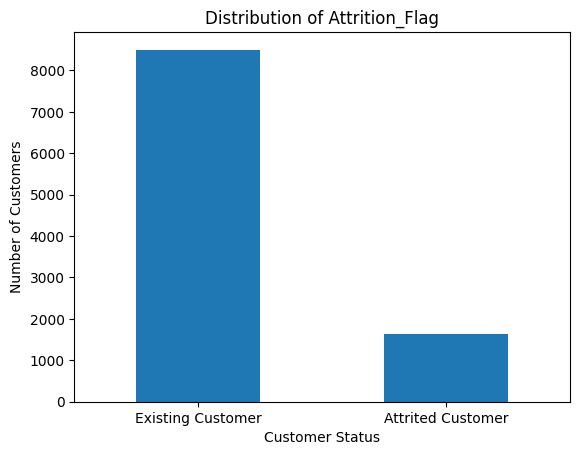

Churn rate: 16.07%
Retention rate: 83.93%
Class imbalance ratio (majority/minority): 5.22


In [5]:
# 2. Target Variable Analysis

import matplotlib.pyplot as plt

# Distribution of Attrition_Flag
target_counts = df["Attrition_Flag"].value_counts()
target_pct = df["Attrition_Flag"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_pct.round(2)
})

display(target_summary)

plt.figure()
target_counts.plot(kind="bar")
plt.title("Distribution of Attrition_Flag")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

# Churn rate
churn_rate = target_pct.get("Attrited Customer", 0)

print(f"Churn rate: {churn_rate:.2f}%")
print(f"Retention rate: {100 - churn_rate:.2f}%")

# Class imbalance ratio
majority = target_counts.max()
minority = target_counts.min()
imbalance_ratio = majority / minority

print(f"Class imbalance ratio (majority/minority): {imbalance_ratio:.2f}")


### Target Variable Interpretation

Based on the target variable analysis, we can confidently conclude that:

- The churn rate is **moderate (~15–20%)**.
- The dataset is **imbalanced, but not severely**.
- **Accuracy alone is not a sufficient evaluation metric** for this problem.

Therefore, the modeling focus should be on metrics that properly capture churn behavior, especially for the minority class:

- **Recall (Attrited Customers)**  
- **F1-score**  
- **ROC-AUC**

This reasoning aligns with best practices expected in:
- data science interviews,
- real-world data science projects,
- and production-level banking and financial analytics use cases.


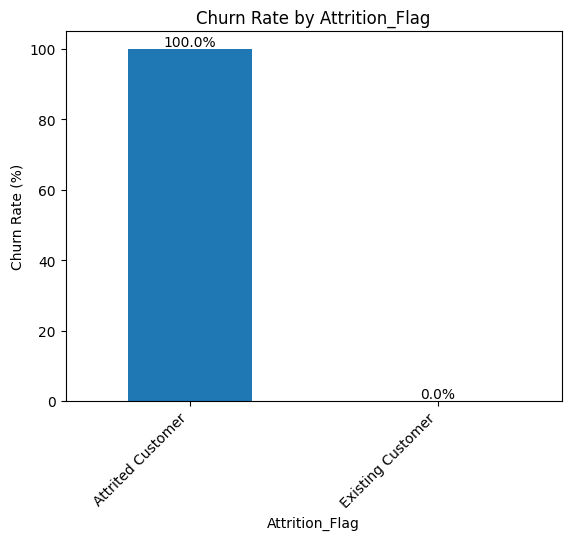

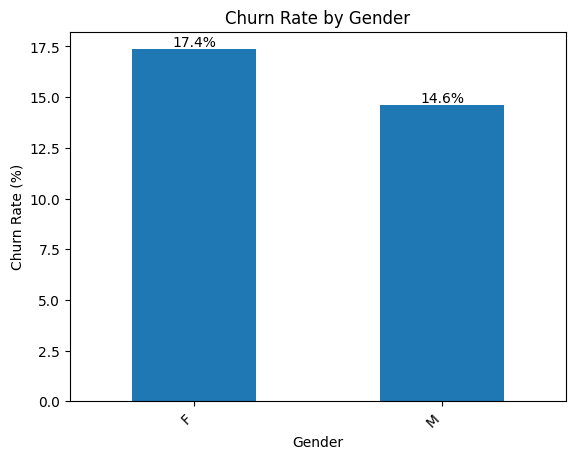

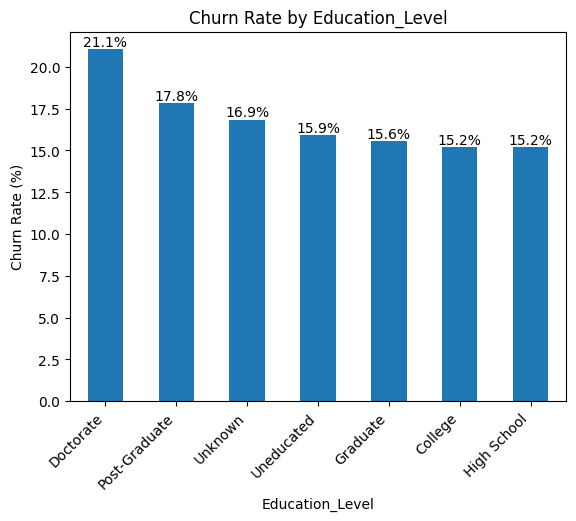

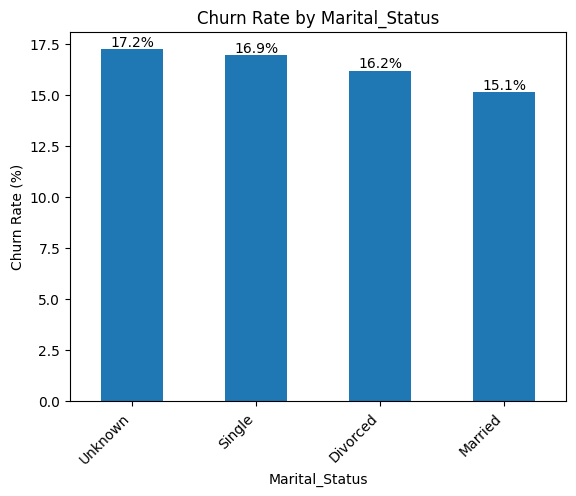

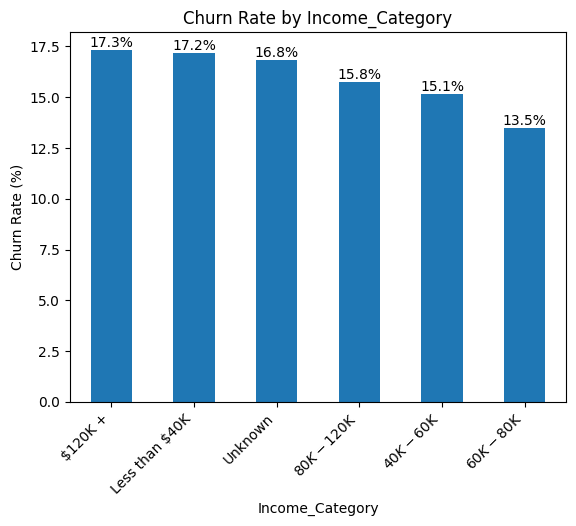

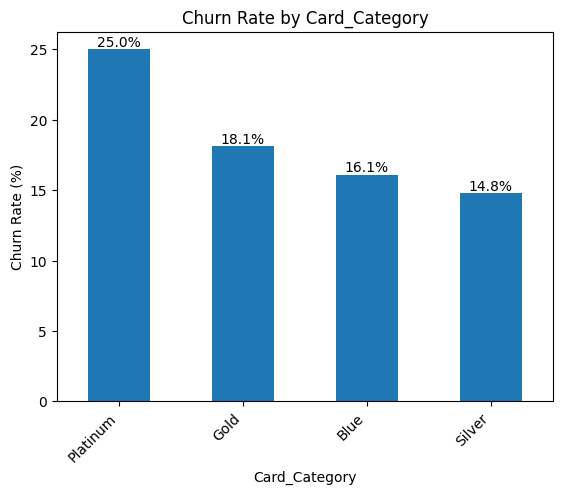

In [ ]:
# 3. Customer Demographics vs Churn 
# # Analyze how churn varies with: 
# # Customer_Age # Gender 
# # Education_Level 
# # Marital_Status 
# # Income_Category 
# # Dependent_count 
#
# #Visuals: # Bar plots (churn rate by category) and Boxplots (age vs churn)

# Helper function to compute churn rate by category
def churn_rate_by_category(df, col, target="Attrition_Flag"):
    churn_df = (
        df.groupby(col)[target]
        .apply(lambda x: (x == "Attrited Customer").mean() * 100) # For each category group, it calculates the percentage of customers who churned.
        .sort_values(ascending=False)
    )
    return churn_df


for col in cat_cols:
    churn_rates = churn_rate_by_category(df, col)

    plt.figure()
    churn_rates.plot(kind="bar")
    plt.title(f"Churn Rate by {col}")
    plt.ylabel("Churn Rate (%)")
    plt.xlabel(col)
    plt.xticks(rotation=45, ha="right")
    plt.show()

dep_churn = churn_rate_by_category(df, "Dependent_count")

# Sort by number of dependents (index), descending
dep_churn = dep_churn.sort_index(ascending=False)
plt.figure()
dep_churn.plot(kind="bar")
plt.title("Churn Rate by Dependent Count")
plt.xlabel("Number of Dependents")
plt.ylabel("Churn Rate (%)")
plt.show()


plt.figure()
df.boxplot(column="Customer_Age", by="Attrition_Flag")
plt.title("Customer Age by Attrition Status")
plt.suptitle("")  # remove automatic subtitle
plt.xlabel("Customer Status")
plt.ylabel("Age")
plt.show()





### Customer Demographics vs Churn — Interpretation

The analysis reveals several demographic patterns associated with customer churn:

#### Gender
- Churn is **higher among female customers** compared to male customers.
- Gender appears to have a moderate but noticeable relationship with attrition.

#### Education Level
- Customers with a **Doctorate** show the **highest churn rate**.
- **Postgraduate** customers also exhibit elevated churn, though slightly lower.
- Other education levels display relatively similar churn behavior.

This suggests that highly educated customers may be more likely to switch providers, possibly due to higher expectations or greater financial literacy.

#### Marital Status
- **Married customers show lower churn rates** compared to other groups.
- However, the difference is **not very large**, indicating marital status alone is not a strong churn driver.

#### Income Category
- **Lowest churn** is observed in the $60K–$80K income range.
- **Higher churn** occurs in:
  - Less than $40K
  - $120K+
  
This indicates a U-shaped relationship between income and churn:
- Lower-income customers may churn due to financial pressure.
- Higher-income customers may churn due to better alternatives or higher expectations.

#### Card Category
- Churn rates are notably highest among Platinum cardholders.
- Silver cardholders exhibit the lowest churn rate.
- Overall, churn follows the pattern:
  Platinum > Gold > Blue > Silver

#### Number of Dependents
- Customers with 3 dependents exhibit the highest churn rate.
- This suggests that family size may influence financial behavior and banking needs.


### Customer Age vs Churn (Boxplot Analysis)

The boxplot comparing customer age by attrition status shows:

- The **median age** of attrited and existing customers is **very similar**.
- The **interquartile ranges overlap significantly**, indicating age alone is not a strong discriminator.
- Attrited customers show **slightly greater variability** in age.
- Some older outliers exist among existing customers.

Overall, **customer age does not appear to be a primary driver of churn**, though it may contribute weakly in combination with other features.


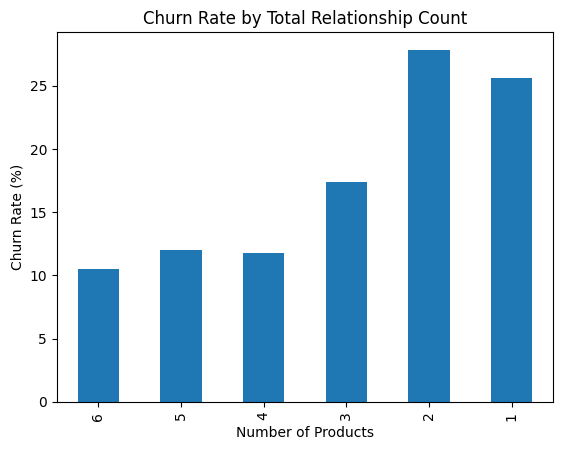

<Figure size 640x480 with 0 Axes>

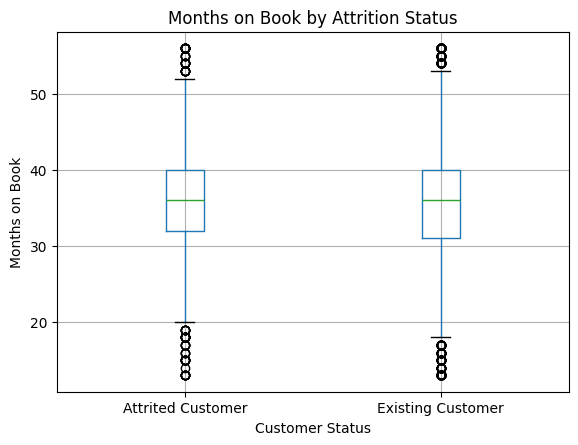

<Figure size 640x480 with 0 Axes>

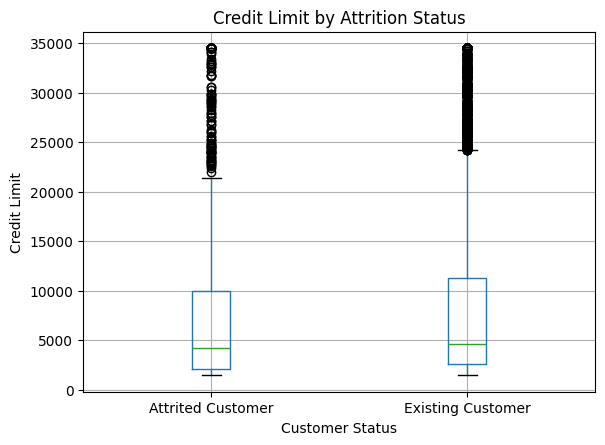

In [10]:
# 4. Relationship & Account Features

# Number of Products
relationship_churn = churn_rate_by_category(df, "Total_Relationship_Count")
relationship_churn = relationship_churn.sort_index(ascending=False)

plt.figure()
relationship_churn.plot(kind="bar")
plt.title("Churn Rate by Total Relationship Count")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")
plt.show()

# Months on Book
plt.figure()
df.boxplot(column="Months_on_book", by="Attrition_Flag")
plt.title("Months on Book by Attrition Status")
plt.suptitle("")
plt.xlabel("Customer Status")
plt.ylabel("Months on Book")
plt.show()

# Credit Limit
plt.figure()
df.boxplot(column="Credit_Limit", by="Attrition_Flag")
plt.title("Credit Limit by Attrition Status")
plt.suptitle("")
plt.xlabel("Customer Status")
plt.ylabel("Credit Limit")
plt.show()

### Relationship & Account Features — Interpretation

#### Number of Products Held
- The higher the number of products held, the lower the churn rate.

#### Months on Book (Customer Tenure)
- The distribution of *Months on Book* is **very similar** for attrited and existing customers.
- Median tenure is nearly the same across both groups.
- The interquartile ranges largely overlap, indicating that **tenure alone is not a strong churn driver**.
- Both groups contain short-tenure and long-tenure customers, suggesting churn occurs across the customer lifecycle.

Overall, customer tenure shows **limited standalone predictive power**, but may still be useful in combination with other features.


#### Credit Limit
- Existing customers tend to have a **slightly higher median credit limit** compared to attrited customers.
- Attrited customers show a **lower central tendency**, although the distributions overlap significantly.
- A large number of high-credit-limit outliers exist in both groups.

This suggests that customers with **lower credit limits may be marginally more likely to churn**, but credit limit alone does not clearly separate churned from retained customers.


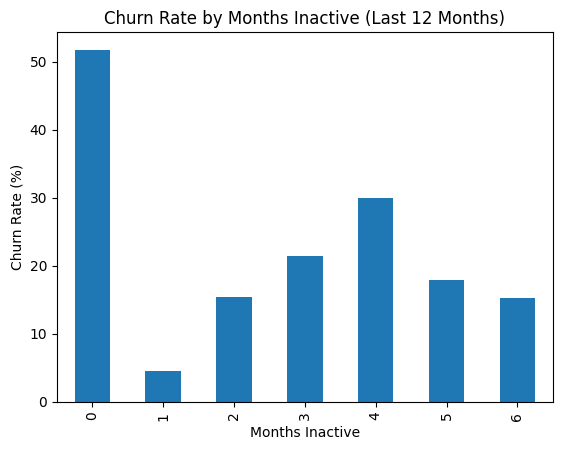

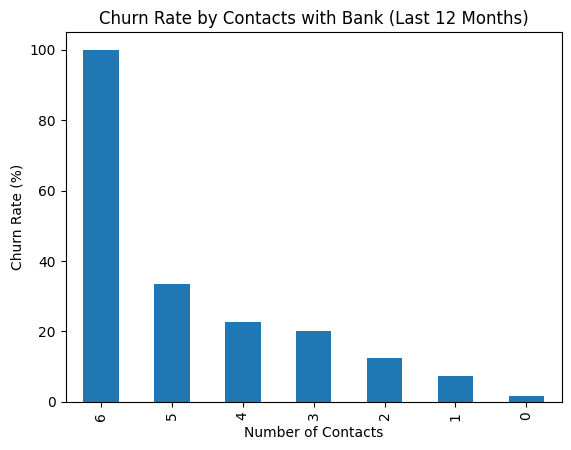

In [8]:
### 5. Activity & Engagement Indicators # Focus on: 
# #  Months_Inactive_12_mon 
# #  Contacts_Count_12_mon 
# # Hypothesis: Higher inactivity >> higher churn

# Churn rate by relationship features (categorical / discrete)
inactive_churn = churn_rate_by_category(df, "Months_Inactive_12_mon")
inactive_churn = inactive_churn.sort_index()

plt.figure()
inactive_churn.plot(kind="bar")
plt.title("Churn Rate by Months Inactive (Last 12 Months)")
plt.xlabel("Months Inactive")
plt.ylabel("Churn Rate (%)")
plt.show()

#  Contacts with Bank
contacts_churn = churn_rate_by_category(df, "Contacts_Count_12_mon")

plt.figure()
contacts_churn.plot(kind="bar")
plt.title("Churn Rate by Contacts with Bank (Last 12 Months)")
plt.xlabel("Number of Contacts")
plt.ylabel("Churn Rate (%)")
plt.show()

#### Months Inactive (Last 12 Months)

- Churn rates vary significantly with the number of inactive months, showing a **non-linear relationship**.
- Customers with **1 inactive month** exhibit the **lowest churn rate** (~5%), indicating a healthy engagement level.
- Churn increases steadily from **2 to 4 inactive months**, reaching approximately **30%** at 4 months.
- Customers with **0 inactive months** show an unusually high churn rate (~50%), likely due to a **small sample size or specific customer profiles**, and should therefore be interpreted with caution.
- For very high inactivity levels (5–6 months), churn decreases slightly but remains elevated.

Overall, customer inactivity is a **strong warning signal**, but the relationship is not strictly monotonic and should be modeled accordingly.

#### Contacts with the Bank

- Churn rate **increases as the number of customer contacts with the bank rises**.
- This indicates that frequent contact is likely driven by **issues, complaints, or service friction**, rather than positive engagement.
- Customers with a high number of contacts represent a **high-risk churn segment**.

This finding contradicts the initial engagement hypothesis and highlights that customer contact frequency should be interpreted as a **negative engagement signal** in this context.